In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/minahilfatima12328/consumer-shopping-trends-analysis/Consumer_Shopping_Trends_2026 (6).csv


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


        Preprocessing  Accuracy  Precision    Recall        F1
0            Raw Data  0.956319   0.927447  0.956319  0.941641
1       Encoding Only  0.958015   0.929278  0.958015  0.943377
2  Encoding + Scaling  0.955047   0.926176  0.955047  0.940375


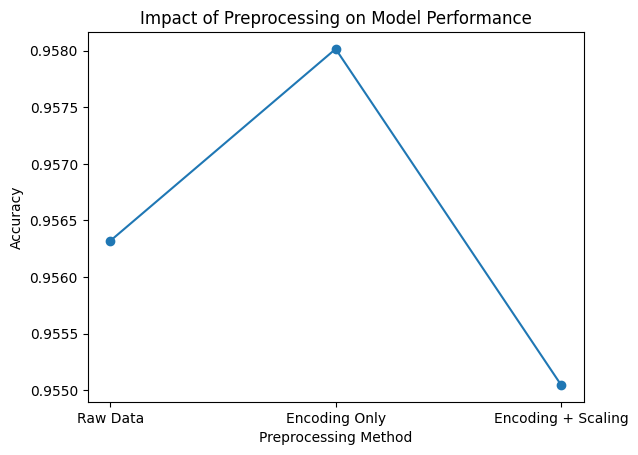

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Load dataset
df = pd.read_csv('/kaggle/input/datasets/minahilfatima12328/consumer-shopping-trends-analysis/Consumer_Shopping_Trends_2026 (6).csv')

# Clean column names
df.columns = df.columns.str.strip()

# Target
target = 'shopping_preference'

results = []

# -------------------------
# 1. Raw Data (minimal processing)
# -------------------------
df1 = df.dropna()
X1 = df1.drop(columns=[target])
y1 = df1[target]

X1 = pd.get_dummies(X1, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X1, y1, test_size=0.2, random_state=42)

model = RandomForestClassifier()
model.fit(X_train, y_train)
preds = model.predict(X_test)

results.append([
    "Raw Data",
    accuracy_score(y_test, preds),
    precision_score(y_test, preds, average='weighted'),
    recall_score(y_test, preds, average='weighted'),
    f1_score(y_test, preds, average='weighted')
])

# -------------------------
# 2. Encoding only
# -------------------------
df2 = df.dropna()
X2 = df2.drop(columns=[target])
y2 = df2[target]

X2 = pd.get_dummies(X2, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

model.fit(X_train, y_train)
preds = model.predict(X_test)

results.append([
    "Encoding Only",
    accuracy_score(y_test, preds),
    precision_score(y_test, preds, average='weighted'),
    recall_score(y_test, preds, average='weighted'),
    f1_score(y_test, preds, average='weighted')
])

# -------------------------
# 3. Encoding + Scaling
# -------------------------
df3 = df.dropna()
X3 = df3.drop(columns=[target])
y3 = df3[target]

X3 = pd.get_dummies(X3, drop_first=True)

scaler = StandardScaler()
X3 = scaler.fit_transform(X3)

X_train, X_test, y_train, y_test = train_test_split(X3, y3, test_size=0.2, random_state=42)

model.fit(X_train, y_train)
preds = model.predict(X_test)

results.append([
    "Encoding + Scaling",
    accuracy_score(y_test, preds),
    precision_score(y_test, preds, average='weighted'),
    recall_score(y_test, preds, average='weighted'),
    f1_score(y_test, preds, average='weighted')
])

# -------------------------
# Results Table
# -------------------------
results_df = pd.DataFrame(results, columns=['Preprocessing','Accuracy','Precision','Recall','F1'])
print(results_df)

# Save table
results_df.to_csv('/kaggle/working/RQ3_table.csv', index=False)

# Plot
plt.figure()
plt.plot(results_df['Preprocessing'], results_df['Accuracy'], marker='o')
plt.title('Impact of Preprocessing on Model Performance')
plt.xlabel('Preprocessing Method')
plt.ylabel('Accuracy')

# Save figure
plt.savefig('/kaggle/working/RQ3_figure.pdf')
plt.show()